## Day 4 — Car Resale Price Prediction using Ridge Regression

Step 1- Load Dataset

In [1]:
import pandas as pd

In [2]:
df=pd.read_csv("/content/car_resale_dataset.csv")
df.head()

,brand,model,year,fuel_type,transmission,km_driven,owner_type,city,mileage,engine_cc,...,estimated_final_price,days_to_sell,bargain_percent,car_age,depreciation_amount,resale_value_percent,demand_score,brand_popularity_score,price_per_km,premium_car
0,Honda,Amaze,2025,Petrol,Manual,11067,Third,Delhi,15,1199,...,739003,20,8,1,236645,75.74,18.45,8,66.78,0
1,Tata,Altroz,2025,Diesel,Automatic,9114,First,Delhi,15,1199,...,579222,21,4,1,130722,81.59,16.54,7,63.55,0
2,Tata,Punch,2021,CNG,Automatic,75049,Second,Delhi,20,1199,...,466743,36,6,5,590414,44.15,3.25,7,6.22,0
3,Maruti,Brezza,2021,Petrol,Manual,74402,Second,Mumbai,19,1462,...,506724,34,5,5,598788,45.84,5.28,9,6.81,0
4,Mahindra,Scorpio,2022,Diesel,Automatic,38984,Second,Delhi,12,2184,...,701332,36,12,4,708120,49.76,8.05,8,17.99,0


In [3]:
df.shape

(200, 23)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 23 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   brand                   200 non-null    object 
 1   model                   200 non-null    object 
 2   year                    200 non-null    int64  
 3   fuel_type               200 non-null    object 
 4   transmission            200 non-null    object 
 5   km_driven               200 non-null    int64  
 6   owner_type              200 non-null    object 
 7   city                    200 non-null    object 
 8   mileage                 200 non-null    int64  
 9   engine_cc               200 non-null    int64  
 10  condition_rating        200 non-null    int64  
 11  original_price          200 non-null    int64  
 12  listed_price            200 non-null    int64  
 13  estimated_final_price   200 non-null    int64  
 14  days_to_sell            200 non-null    in

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.describe()

,year,km_driven,mileage,engine_cc,condition_rating,original_price,listed_price,estimated_final_price,days_to_sell,bargain_percent,car_age,depreciation_amount,resale_value_percent,demand_score,brand_popularity_score,price_per_km,premium_car
count,200.000000,200.000000,200.00000,200.000000,200.00000,2.000000e+02,2.000000e+02,2.000000e+02,200.000000,200.000000,200.000000,2.000000e+02,200.000000,200.000000,200.000000,200.000000,200.000000
mean,2020.785000,63461.430000,18.51500,1417.000000,6.97500,1.371487e+06,6.940533e+05,6.409128e+05,34.070000,8.410000,5.215000,7.305739e+05,47.327350,5.562000,7.490000,22.911750,0.130000
std,3.622761,47226.542849,4.13464,433.747408,1.48506,7.225131e+05,4.578551e+05,4.296006e+05,8.269645,2.885051,3.622761,5.651384e+05,21.604726,8.577101,1.403477,29.882983,0.337147
min,2010.000000,8131.000000,12.00000,999.000000,5.00000,5.103400e+05,7.655100e+04,6.889500e+04,18.000000,3.000000,1.000000,1.307220e+05,12.600000,-15.940000,5.000000,0.420000,0.000000
25%,2019.000000,29013.000000,15.00000,1197.000000,5.00000,8.985250e+05,3.999405e+05,3.637055e+05,28.000000,6.000000,2.000000,4.043812e+05,28.827500,-0.907500,7.000000,4.370000,0.000000
50%,2022.000000,50760.000000,19.00000,1199.000000,7.00000,1.092096e+06,5.896840e+05,5.544590e+05,32.500000,8.000000,4.000000,6.057975e+05,50.190000,7.590000,8.000000,12.160000,0.000000
75%,2024.000000,84226.000000,22.00000,1497.000000,8.00000,1.580006e+06,8.689598e+05,8.086520e+05,39.250000,10.000000,7.000000,8.833492e+05,66.892500,12.777500,8.000000,28.340000,0.000000
max,2025.000000,232796.000000,25.00000,2755.000000,10.00000,4.627798e+06,2.370945e+06,2.181269e+06,56.000000,16.000000,16.000000,4.044697e+06,82.220000,18.500000,10.000000,197.400000,1.000000


step 2 - Understand the target

In [7]:
# Check Relationships
df.corr(numeric_only=True)["estimated_final_price"].sort_values(ascending=False)

,estimated_final_price
estimated_final_price,1.000000
listed_price,0.998906
price_per_km,0.746139
resale_value_percent,0.650549
demand_score,0.629683
year,0.629084
original_price,0.623728
condition_rating,0.594878
premium_car,0.559492
engine_cc,0.550249


In [8]:
# also check the categorial columns

categorical_columns = df.select_dtypes(include="object").columns
for col in categorical_columns:
  print("\n"+"="*50)
  print("Column :",col)
  print("Unique :",df[col].nunique())
  print(df[col].value_counts())


Column : brand
Unique : 8
brand
Renault     34
Kia         31
Honda       29
Maruti      24
Hyundai     23
Tata        23
Mahindra    21
Toyota      15
Name: count, dtype: int64

Column : model
Unique : 27
model
Triber      13
Seltos      13
Kiger       12
Jazz        11
i20         10
XUV700      10
Sonet        9
Nexon        9
City         9
Kwid         9
Amaze        9
Carens       9
Dzire        8
Venue        7
Glanza       6
Brezza       6
Thar         6
Punch        6
Harrier      6
Fortuner     5
Baleno       5
Scorpio      5
Swift        5
Innova       4
Verna        3
Creta        3
Altroz       2
Name: count, dtype: int64

Column : fuel_type
Unique : 3
fuel_type
Petrol    126
Diesel     58
CNG        16
Name: count, dtype: int64

Column : transmission
Unique : 2
transmission
Automatic    110
Manual        90
Name: count, dtype: int64

Column : owner_type
Unique : 3
owner_type
Second    70
First     68
Third     62
Name: count, dtype: int64

Column : city
Unique : 8
city
D

Step 3 - Select Features
Model 1 — With *listed_price*

Scenario A — Predict final resale price from listing information

If the business situation is:

"The seller has already decided the listed price, and we want to estimate the final selling price."

Then:

listed_price → available before prediction

✅ Keep it.

This is actually a realistic model.

In [10]:
leakage_columns=[
    "estimated_final_price",
    "depreciation_amount",
    "resale_value_percent",
    "price_per_km",
    "bargain_percent",
    "days_to_sell"
]

x=df.drop(columns=leakage_columns)
y=df['estimated_final_price']

print("X-Shape :",x.shape)
print("Y-Shape :",y.shape)

X-Shape : (200, 17)
Y-Shape : (200,)


Step 4: Train/Test Split

In [12]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test=train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train:", x_train.shape)
print("X_test :", x_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (160, 17)
X_test : (40, 17)
y_train: (160,)
y_test : (40,)


Step 5 — Encoding + Scaling

In [13]:
# identify the columns

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numerical_feature=x.select_dtypes(
    include=["int64",'float64']
).columns.tolist()

categorical_feature=x.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical Features :")
print(numerical_feature)

print("\n Categorical Features :")
print(categorical_feature)

Numerical Features :
['year', 'km_driven', 'mileage', 'engine_cc', 'condition_rating', 'original_price', 'listed_price', 'car_age', 'demand_score', 'brand_popularity_score', 'premium_car']

 Categorical Features :
['brand', 'model', 'fuel_type', 'transmission', 'owner_type', 'city']


In [14]:
from sklearn import preprocessing
# create the preprocessing system
preprocessor = ColumnTransformer(
    transformers=[
        ("num",StandardScaler(),numerical_feature),
        ("cat",OneHotEncoder(handle_unknown="ignore"),categorical_feature)
    ]
)

Step 6 — Build Ridge Regression Pipeline

In [15]:
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline

ridge_model=Pipeline([
    ("preprocessor",preprocessor),
    ('ridge',Ridge(alpha=1.0))
])

Step 7 — Train the Ridge Model

In [17]:
# Train the ridge model
ridge_model.fit(x_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['year', 'km_driven',
                                                   'mileage', 'engine_cc',
                                                   'condition_rating',
                                                   'original_price',
                                                   'listed_price', 'car_age',
                                                   'demand_score',
                                                   'brand_popularity_score',
                                                   'premium_car']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['brand', 'model',
                                                   'fuel_type', 'transmission',
                                                   'owner_type', 'city'])])),
                ('ridge', Ridge())])

Step 8 — Make Predictions

In [18]:
# Make prediction
y_pred=ridge_model.predict(x_test)

print(y_pred[:10])

[ 469081.78790093  464577.45875923  738812.65793097 1066442.48045058
  903884.42293791  569613.12042793  913199.79916994 1384282.63901714
  572306.75956903  129033.01698547]


In [22]:
pd.set_option('display.float_format',lambda x:f'{x:1f}')

result=pd.DataFrame({
    "Actual":y_test.values,
    "Predict":y_pred
})

print(result.head())

    Actual        Predict
0   445787  469081.787901
1   475939  464577.458759
2   665524  738812.657931
3  1018708 1066442.480451
4   903269  903884.422938


Step 9 — Evaluate the Model

In [23]:
from sklearn.metrics import(
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import numpy as np

mae=mean_absolute_error(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
rmse=np.sqrt(mse)
r2=r2_score(y_test,y_pred)

print("Ridge Regression")
print("MAE :",mae)
print("MSe :",mse)
print("RMSE :",rmse)
print("R2 :",r2)

Ridge Regression
MAE : 18382.056723641854
MSe : 597671135.8569227
RMSE : 24447.313469109908
R2 : 0.9969364180080783


In [25]:
df[
    [
        "original_price",
        "listed_price",
        "estimated_final_price"
    ]
].corr()

,original_price,listed_price,estimated_final_price
original_price,1.000000,0.632501,0.623728
listed_price,0.632501,1.000000,0.998906
estimated_final_price,0.623728,0.998906,1.000000


In [24]:
df[
    [
        "original_price",
        "listed_price",
        "estimated_final_price"
    ]
].head()

,original_price,listed_price,estimated_final_price
0,975648,803265,739003
1,709944,603357,579222
2,1057157,496536,466743
3,1105512,533394,506724
4,1409452,796969,701332


Model 2 — Without *listed_price*

Scenario B — Predict resale price before deciding the listing price

If the goal is:

"Given the car's characteristics, determine what price we should list it for."

Then listed_price shouldn't be used.

❌ Remove it.

In [38]:
x1=df.drop(columns=[
    "estimated_final_price",
    "depreciation_amount",
    "resale_value_percent",
    "price_per_km",
    "bargain_percent",
    "days_to_sell",
    "listed_price"
])

y1=df['estimated_final_price']

print(x1.shape)
print(y1.shape)

(200, 16)
(200,)


Redo Train/Test Split for without listed price

In [46]:
x1_train,x1_test,y1_train,y1_test  = train_test_split(
    x1,
    y1,
    test_size=0.2,
    random_state=42
)

print("X1_train:", x1_train.shape)
print("X1_test :", x1_test.shape)
print("y1_train:", y1_train.shape)
print("y1_test :", y1_test.shape)

X1_train: (160, 16)
X1_test : (40, 16)
y1_train: (160,)
y1_test : (40,)


Identify Features Again without listed_price

In [47]:
numeric_features=x1.select_dtypes(
    include=["int64","float64"]
).columns.tolist()

categorical_features=x1.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical Features:")
print(numeric_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
['year', 'km_driven', 'mileage', 'engine_cc', 'condition_rating', 'original_price', 'car_age', 'demand_score', 'brand_popularity_score', 'premium_car']

Categorical Features:
['brand', 'model', 'fuel_type', 'transmission', 'owner_type', 'city']


Recreate Preprocessor

In [54]:
preprocessor=ColumnTransformer(
    transformers=[
        ('num',StandardScaler(),numeric_features),
        ("cat",OneHotEncoder(handle_unknown="ignore"),categorical_features)
    ]
)

Create a new ridge Model

In [55]:
ridge_model=Pipeline([
    ("preprocessor",preprocessor),
    ("ridge",Ridge(alpha=1.0))
])

In [56]:
ridge_model.fit(x1_train,y1_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['year', 'km_driven',
                                                   'mileage', 'engine_cc',
                                                   'condition_rating',
                                                   'original_price', 'car_age',
                                                   'demand_score',
                                                   'brand_popularity_score',
                                                   'premium_car']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['brand', 'model',
                                                   'fuel_type', 'transmission',
                                                   'owner_type', 'city'])])),
                ('ridge', Ridge())])

In [57]:
y_pred1=ridge_model.predict(x1_test)

In [58]:
result1=pd.DataFrame({
    "Actual":y1_test.values,
    "Predicted":y_pred1
})

print(result.head())

    Actual        Predict
0   445787  469081.787901
1   475939  464577.458759
2   665524  738812.657931
3  1018708 1066442.480451
4   903269  903884.422938


In [59]:
mae = mean_absolute_error(y1_test, y_pred1)
mse = mean_squared_error(y1_test, y_pred1)
rmse = np.sqrt(mse)
r2 = r2_score(y1_test, y_pred1)

print("Ridge Regression WITHOUT Listed Price")
print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R²  :", r2)

Ridge Regression WITHOUT Listed Price
MAE : 121257.04959043278
MSE : 23357980153.098244
RMSE: 152833.17752732305
R²  : 0.8802701300572306


Linear Regression Baseline

In [60]:
from sklearn.linear_model import LinearRegression

linear_model=Pipeline([
    ("preprocessor",preprocessor),
    ("linear",LinearRegression())
])

linear_model.fit(x1_train,y1_train)
linear_pred=linear_model.predict(x_test)

In [61]:
linear_mae = mean_absolute_error(y_test, linear_pred)
linear_mse = mean_squared_error(y_test, linear_pred)
linear_rmse = np.sqrt(linear_mse)
linear_r2 = r2_score(y_test, linear_pred)

print("Linear Regression")
print("MAE :", linear_mae)
print("MSE :", linear_mse)
print("RMSE:", linear_rmse)
print("R²  :", linear_r2)

Linear Regression
MAE : 132094.1469024191
MSE : 26256935679.604393
RMSE: 162039.92001850775
R²  : 0.8654104732768299


Test with multiple alpha values

In [63]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "ridge__alpha": [0.01, 0.1, 1, 10, 100, 1000]
}

grid_search = GridSearchCV(
    ridge_model,
    param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid_search.fit(x1_train, y1_train)

print("Best Alpha:", grid_search.best_params_)
print("Best CV R²:", grid_search.best_score_)

Best Alpha: {'ridge__alpha': 10}
Best CV R²: 0.8372260479695237


In [64]:
# Then evaluate the tuned model
best_ridge = grid_search.best_estimator_

best_pred = best_ridge.predict(x1_test)

best_mae = mean_absolute_error(y1_test, best_pred)
best_mse = mean_squared_error(y1_test, best_pred)
best_rmse = np.sqrt(best_mse)
best_r2 = r2_score(y1_test, best_pred)

print("Tuned Ridge Regression")
print("Best Alpha:", grid_search.best_params_["ridge__alpha"])
print("MAE :", best_mae)
print("MSE :", best_mse)
print("RMSE:", best_rmse)
print("R²  :", best_r2)

Tuned Ridge Regression
Best Alpha: 10
MAE : 128010.64127185955
MSE : 28242175388.195385
RMSE: 168054.08471142672
R²  : 0.8552344010926392


First, let's create the final model cleanly:

In [66]:
final_ridge = Pipeline([
    ("preprocessor", preprocessor),
    ("ridge", Ridge(alpha=1.0))
])

final_ridge.fit(x1_train, y1_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['year', 'km_driven',
                                                   'mileage', 'engine_cc',
                                                   'condition_rating',
                                                   'original_price', 'car_age',
                                                   'demand_score',
                                                   'brand_popularity_score',
                                                   'premium_car']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['brand', 'model',
                                                   'fuel_type', 'transmission',
                                                   'owner_type', 'city'])])),
                ('ridge', Ridge())])

In [67]:
final_pred = final_ridge.predict(x1_test)

print("Final Ridge Model")
print("MAE :", mean_absolute_error(y1_test, final_pred))
print("MSE :", mean_squared_error(y1_test, final_pred))
print("RMSE:", np.sqrt(mean_squared_error(y1_test, final_pred)))
print("R²  :", r2_score(y1_test, final_pred))

Final Ridge Model
MAE : 121257.04959043278
MSE : 23357980153.098244
RMSE: 152833.17752732305
R²  : 0.8802701300572306


Let's test with new car data

In [68]:
new_car = pd.DataFrame({
    "brand": ["Toyota"],
    "model": ["Corolla"],
    "year": [2021],
    "fuel_type": ["Petrol"],
    "transmission": ["Automatic"],
    "km_driven": [35000],
    "owner_type": ["First Owner"],
    "city": ["Kathmandu"],
    "mileage": [18],
    "engine_cc": [1800],
    "condition_rating": [8],
    "original_price": [3500000],
    "car_age": [5],
    "demand_score": [8.5],
    "brand_popularity_score": [9],
    "premium_car": [0]
})

new_car

,brand,model,year,fuel_type,transmission,km_driven,owner_type,city,mileage,engine_cc,condition_rating,original_price,car_age,demand_score,brand_popularity_score,premium_car
0,Toyota,Corolla,2021,Petrol,Automatic,35000,First Owner,Kathmandu,18,1800,8,3500000,5,8.500000,9,0


In [69]:
# predict the resale price
predicted_price = final_ridge.predict(new_car)

print("Predicted Resale Price:", predicted_price[0])

Predicted Resale Price: 1379215.3797207526


Multiple new cars

In [70]:
new_cars = pd.DataFrame({
    "brand": ["Toyota", "Honda", "Hyundai", "BMW", "Maruti"],
    "model": ["Corolla", "Civic", "Creta", "3 Series", "Swift"],
    "year": [2021, 2020, 2022, 2019, 2021],
    "fuel_type": ["Petrol", "Petrol", "Diesel", "Petrol", "Petrol"],
    "transmission": ["Automatic", "Automatic", "Manual", "Automatic", "Manual"],
    "km_driven": [35000, 42000, 28000, 55000, 30000],
    "owner_type": ["First Owner", "First Owner", "First Owner", "Second Owner", "First Owner"],
    "city": ["Kathmandu", "Kathmandu", "Pokhara", "Kathmandu", "Lalitpur"],
    "mileage": [18, 17, 20, 15, 23],
    "engine_cc": [1800, 1500, 1600, 2000, 1200],
    "condition_rating": [8, 8, 9, 7, 9],
    "original_price": [3500000, 4000000, 3200000, 7500000, 2500000],
    "car_age": [5, 6, 4, 7, 5],
    "demand_score": [8.5, 8.0, 8.7, 7.5, 8.8],
    "brand_popularity_score": [9, 9, 8, 9, 8],
    "premium_car": [0, 0, 0, 1, 0]
})

new_predictions = final_ridge.predict(new_cars)

prediction_df = new_cars[["brand", "model", "year"]].copy()
prediction_df["Predicted Resale Price"] = new_predictions

prediction_df

,brand,model,year,Predicted Resale Price
0,Toyota,Corolla,2021,1379215.379721
1,Honda,Civic,2020,1656609.420469
2,Hyundai,Creta,2022,1547838.793322
3,BMW,3 Series,2019,2926762.280167
4,Maruti,Swift,2021,1112796.445701


Actual vs Predicted Visualization

In [71]:
comparison_df = pd.DataFrame({
    "Actual Price": y1_test.values,
    "Predicted Price": final_pred
})

comparison_df.head(10)

,Actual Price,Predicted Price
0,445787,491905.022944
1,475939,444724.718926
2,665524,1010422.653311
3,1018708,1173293.093847
4,903269,784569.949016
5,560689,577252.484713
6,894650,1033648.790612
7,1394288,1195020.023359
8,566082,601010.478176
9,143031,47507.787067


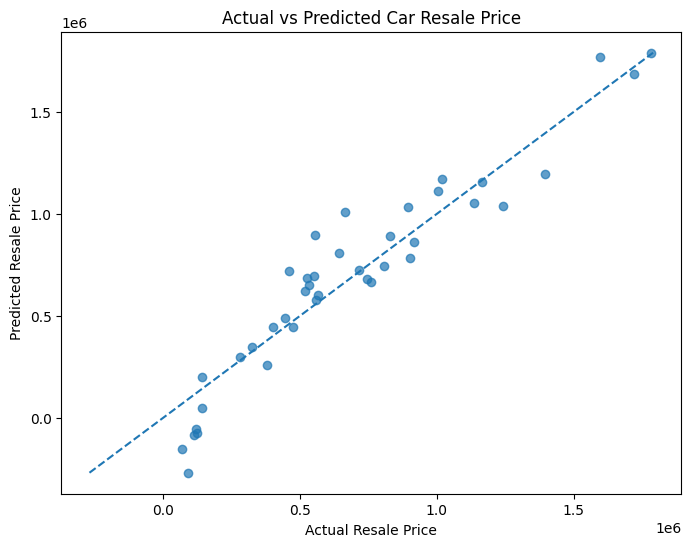

In [72]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(
    comparison_df["Actual Price"],
    comparison_df["Predicted Price"],
    alpha=0.7
)

plt.xlabel("Actual Resale Price")
plt.ylabel("Predicted Resale Price")
plt.title("Actual vs Predicted Car Resale Price")

# Perfect prediction line
min_price = min(
    comparison_df["Actual Price"].min(),
    comparison_df["Predicted Price"].min()
)

max_price = max(
    comparison_df["Actual Price"].max(),
    comparison_df["Predicted Price"].max()
)

plt.plot(
    [min_price, max_price],
    [min_price, max_price],
    linestyle="--"
)

plt.show()

In [73]:
import joblib

joblib.dump(final_ridge,"Ridge Regression_Car_Resale_Price_Prediction.pkl")


['Ridge Regression_Car_Resale_Price_Prediction.pkl']